## Thesis Chapter 3: Neural underpinnings of DD -- on sciencecloud

1. 'computational space' hypothesis testing with nPRF model params: r2 maps

DAN-patch plots generated in `nets_PFM/npc_net_ana.ipynb`


In [46]:
import os.path as op    
import nibabel as nib
import numpy as np
import pandas as pd

bids_folder = '/mnt_03/ds-dnumrisk'
group_df = pd.read_csv(op.join(bids_folder, 'group_assignment.csv')).set_index('subject')

BIDS_ROOT_LARGE  = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
plot_folder = op.join(BIDS_ROOT_LARGE, 'thesis_materials')

param = 'r2' # 

if param == 'cvr2':
    nPRF_folder = op.join(bids_folder, 'derivatives/encoding_model.cv.denoise')
elif param == 'r2':
    nPRF_folder = op.join(bids_folder, 'derivatives/encoding_model.denoise')

subList = np.arange(1, 67) # 1-66
subList = subList[subList != 3] # remove sub-09
group_df = group_df.loc[subList]


In [47]:
from parietal_patterns.utils.surfaces import get_NPC_mask, get_basic_mask
npc_mask = get_NPC_mask(space='fsaverage5', hemi='both') # (20484,)
npc_mask_L = get_NPC_mask(space='fsaverage5', hemi='L') 
npc_mask_R = get_NPC_mask(space='fsaverage5', hemi='R')

# not needed now
brain_mask, _ = get_basic_mask() # default is fsaverage5, hemi='both' (20484,)
npc_mask_cortex = npc_mask[brain_mask] # 59412
npc_mask_cortex.shape

(18715,)

### Statistics: subjectwise measure - between group comparison

In [ ]:
r2_treshold = 0.05
rows = []
for sub in subList:
    nPRFmap_L = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-L.func.gii')).agg_data()
    nPRFmap_R = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii')).agg_data()
    nPRFmap_fsav5 = np.concatenate([nPRFmap_L, nPRFmap_R], axis=0)#[mask]

    nPRF_NPC = nPRFmap_fsav5[npc_mask]
    nPRF_NPC_L = nPRFmap_fsav5[npc_mask_L]
    npRF_NPC_R = nPRFmap_fsav5[npc_mask_R]
    rows.append({'mean_R2': nPRF_NPC.mean(),
                'mean_R2_L': nPRF_NPC_L.mean(),
                'mean_R2_R': npRF_NPC_R.mean(),
                'area(r2>0.01)': (nPRF_NPC > 0.01).sum(),
                'area(r2>0.05)': (nPRF_NPC > 0.05).sum(),
                'area(r2>0.1)': (nPRF_NPC > 0.1).sum(),
                })
                #'area(r2>)': (nPRF_NPC > r2_treshold).sum(),
                #'area(r2>)_L': (nPRF_NPC_L > r2_treshold).sum(),
                #'area(r2>)_R': (npRF_NPC_R > r2_treshold).sum()})

df = pd.DataFrame(rows, index=pd.Index(subList, name='subject')).join(group_df, how='inner').set_index('group', append=True)
#df.to_csv(op.join(PHENOTYPE_DIR, 'nPRF_R2area.csv'))

In [64]:
from parietal_patterns.utils.statistics import between_group_comparison

for col in df.columns:
    print(f'--- {col} ---')
    stats, stats_terms = between_group_comparison(df, col, group_names = [0,1])
    print(f'{stats_terms}={stats.statistic}, p={stats.pvalue:02f}')


--- mean_R2 ---
U(32, 33)=705.0, p=0.020560
--- mean_R2_L ---
U(32, 33)=717.0, p=0.013383
--- mean_R2_R ---
U(32, 33)=699.0, p=0.025271
--- area(r2>0.01) ---
U(32, 33)=720.5, p=0.011755
--- area(r2>0.05) ---
U(32, 33)=711.0, p=0.016566
--- area(r2>0.1) ---
U(32, 33)=611.5, p=0.196113


In [38]:
# correlate with neural precision

BIDS_ROOT = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'

PHENOTYPE_DIR = BIDS_ROOT + '/derivatives/phenotype'

from numrisk.behavior_general.measures_registry import _load_decode_r
nPRF_r = _load_decode_r(dir_=PHENOTYPE_DIR)

movement_FD = pd.read_csv(op.join(PHENOTYPE_DIR, 'fMRI_movement_FD.csv')).set_index('subject')

In [ ]:
df_comb = nPRF_r.join(df).join(movement_FD)
df_comb.corr()[['r','mean_R2']]

# r & mean-NPC-R2 correlate substantially - mean-NPC-R2 less with movement though

,r,mean_R2
r,1.000000,0.627992
mean_R2,0.627992,1.000000
mean_R2_L,0.585550,0.934261
mean_R2_R,0.600397,0.954515
area(r2>0.01),0.509786,0.817124
area(r2>0.05),0.604388,0.973715
area(r2>0.1),0.411996,0.765690
overall_mean,-0.194064,-0.131584
overall_max,-0.155919,-0.100673


### Visualization: group wise averages on brain surface 

In [48]:
hemi = 'R'
rows_DD = []
rows_HC = []

for sub in subList:
    nPRFmap_L = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-L.func.gii')).agg_data()
    nPRFmap_R = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii')).agg_data()
    nPRFmap_fsav5 = np.concatenate([nPRFmap_L, nPRFmap_R], axis=0)#[mask]

    nPRF_NPC = nPRFmap_fsav5[npc_mask]
    
    if group_df.loc[sub, 'group'] == 0:
        rows_HC.append(nPRF_NPC)
    elif group_df.loc[sub, 'group'] == 1:
        rows_DD.append(nPRF_NPC)

df_HC = pd.DataFrame(rows_HC, index=pd.Index(subList, name='subject')[group_df['group'] == 0])
df_DD = pd.DataFrame(rows_DD, index=pd.Index(subList, name='subject')[group_df['group'] == 1])

df_HC.mean(axis=0).shape, df_DD.mean(axis=0).shape

((1510,), (1510,))

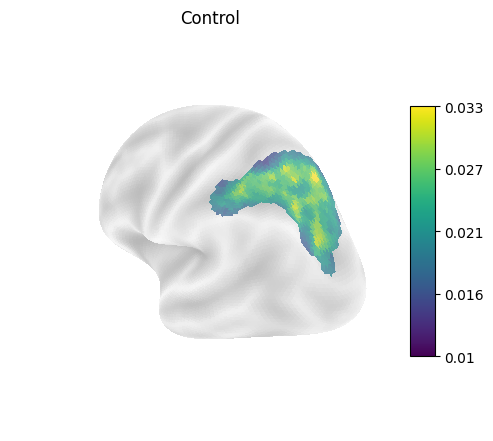

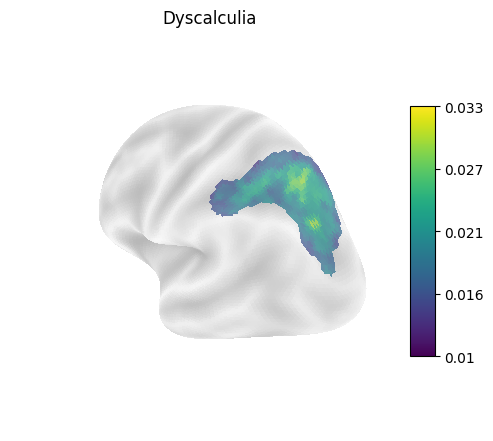

In [ ]:
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt


hemi_to_plot = 'L' # 'R'
i_hemi_to_plot = 0 if hemi_to_plot == 'L' else 1  

cmap = 'viridis' 
view = (30, 220) if hemi == 'L' else (30, -30) # (elev, azim) in degrees -- tweak freely
vmin = 0.01
vmax = 0.033

fsaverage = fetch_surf_fsaverage('fsaverage5') 
surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

# HC
cortex_map = np.repeat(np.nan, 20484) #np.zeros(20484)
cortex_map[npc_mask] = df_HC.mean(axis=0).values
surf_map_hemi = np.split(cortex_map,2)[i_hemi_to_plot]
nplt.plot_surf(surf_mesh=surf_mesh , surf_map= surf_map_hemi, avg_method = 'median',# infl_right # pial_right
        view= view,cmap=cmap, colorbar=True,title='Control',
        vmin = vmin, vmax=vmax,
        bg_map=bg_map, bg_on_data=True,darkness=0.3) 
plt.show()

# DD
cortex_map = np.repeat(np.nan, 20484) #np.zeros(20484)
cortex_map[npc_mask] = df_DD.mean(axis=0).values
surf_map_hemi = np.split(cortex_map,2)[i_hemi_to_plot]
nplt.plot_surf(surf_mesh=surf_mesh , surf_map= surf_map_hemi, avg_method = 'median',# infl_right # pial_right
        view= view,cmap=cmap, colorbar=True, title='Dyscalculia',
        vmin = vmin, vmax=vmax,
        bg_map=bg_map, bg_on_data=True,darkness=0.3) 
plt.show()

### Summary figure: Control vs. Dyscalculia, L vs. R (thesis figure)

Rows = group (labeled), cols = hemisphere (L, R — unlabeled, placed adjacently like a
whole brain). Each panel is rendered standalone and auto-cropped, then composed as
flat images — `Axes3D` subplots ignore `subplots_adjust`/`hspace`, so packing them via
`plt.subplots` directly leaves large gaps. Saved as PDF to `plot_folder` for direct
inclusion in the thesis.

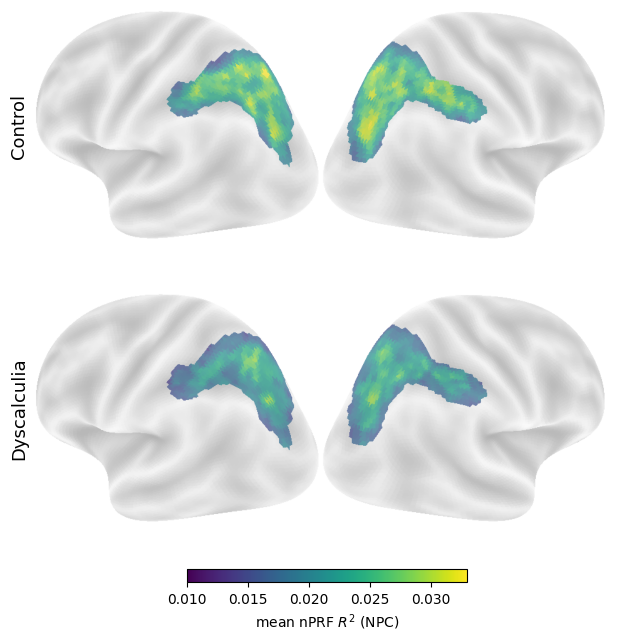

In [53]:
import io
from PIL import Image

view_L = (30, 30 + (360/2))
view_R = (30, -30)

def render_surf_panel(surf_mesh, bg_map, surf_map_hemi, view):
    fig_panel = plt.figure(figsize=(4, 4))
    ax_panel = fig_panel.add_subplot(111, projection='3d')
    nplt.plot_surf(surf_mesh=surf_mesh, surf_map=surf_map_hemi, avg_method='median',
                    view=view, cmap=cmap, colorbar=False,
                    vmin=vmin, vmax=vmax, bg_map=bg_map, bg_on_data=True, darkness=0.3,
                    axes=ax_panel, figure=fig_panel)
    buf = io.BytesIO()
    fig_panel.savefig(buf, format='png', dpi=200, bbox_inches='tight', pad_inches=0)
    plt.close(fig_panel)
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    # auto-crop whitespace so panels pack tightly in the grid
    arr = np.array(img)
    nonwhite = np.any(arr < 250, axis=-1)
    r0, r1 = np.where(np.any(nonwhite, axis=1))[0][[0, -1]]
    c0, c1 = np.where(np.any(nonwhite, axis=0))[0][[0, -1]]
    pad = 5
    r0, c0 = max(r0 - pad, 0), max(c0 - pad, 0)
    r1, c1 = min(r1 + pad, arr.shape[0]), min(c1 + pad, arr.shape[1])
    return img.crop((c0, r0, c1, r1))

col_specs = [('L', fsaverage.infl_left, fsaverage.sulc_left, 0, view_L),
             ('R', fsaverage.infl_right, fsaverage.sulc_right, 1, view_R)]
row_specs = [('Control', df_HC), ('Dyscalculia', df_DD)]

panel_imgs = {}
for hemi, surf_mesh_col, bg_map_col, i_hemi, view in col_specs:
    for label, df_group in row_specs:
        cortex_map = np.full(20484, np.nan)
        cortex_map[npc_mask] = df_group.mean(axis=0).values
        surf_map_hemi = np.split(cortex_map, 2)[i_hemi]
        panel_imgs[(label, hemi)] = render_surf_panel(surf_mesh_col, bg_map_col, surf_map_hemi, view)

fig, axes = plt.subplots(2, 2, figsize=(7, 6.5))
for i_row, (label, _) in enumerate(row_specs):
    for i_col, (hemi, *_) in enumerate(col_specs):
        ax = axes[i_row, i_col]
        ax.imshow(panel_imgs[(label, hemi)])
        ax.axis('off')
    axes[i_row, 0].text(-0.05, 0.5, label, transform=axes[i_row, 0].transAxes,
                         rotation=90, va='center', ha='center', fontsize=13)

fig.subplots_adjust(wspace=0.0, hspace=0.05, bottom=0.1, top=0.95, left=0.08)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar_ax = fig.add_axes([0.3, 0.04, 0.4, 0.02])
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='mean nPRF $R^2$ (NPC)')

fig.savefig(op.join(plot_folder, 'ch3_nPRF_R2_NPC_group_hemi.pdf'), bbox_inches='tight')
plt.show()